<a href="https://colab.research.google.com/github/Malek04/radiomics_simple/blob/main/radiomics_simple.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 Radiomics — Version simple



In [1]:
# Installation
!pip install -q SimpleITK pandas numpy Pillow openpyxl matplotlib
!pip install -q "git+https://github.com/AIM-Harvard/pyradiomics.git"
print("Installation terminée.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 10.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 4.3 MB/s eta 0:00:00
Installation terminée.


In [2]:
import os
import logging
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk
from radiomics import featureextractor
from PIL import Image

warnings.filterwarnings('ignore')
logging.getLogger('radiomics').setLevel(logging.ERROR)

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

MEDICAL_EXTS = ('.dcm', '.nii', '.nii.gz', '.nrrd', '.mha', '.mhd')

def load_as_sitk(path):
    lower = path.lower()
    if lower.endswith(MEDICAL_EXTS):
        return sitk.ReadImage(path)
    else:
        pil_img = Image.open(path).convert('L')
        arr = np.array(pil_img)
        return sitk.GetImageFromArray(arr)

print("Environnement prêt.")

Environnement prêt.


## Étape 1 : Charger l'image et définir la VOI (masque)

D'abord l'image, puis le masque. Si vous n'avez pas de masque tout prêt, 3 options :
- **`upload_mask`** : vous avez un fichier masque (créé par ex. avec 3D Slicer / ITK-SNAP)
- **`rectangle`** : vous définissez un rectangle autour de la zone d'intérêt, à l'aide de la grille de coordonnées affichée
- **`otsu`** : seuillage automatique (utile si la lésion contraste bien avec le fond)
- **`full_image`** : pas de VOI précise, toute l'image sert de zone d'analyse (déconseillé pour un vrai usage clinique)

Sélectionnez votre image :


Saving WhatsApp Image 2026-07-09 at 18.47.54.jpeg to WhatsApp Image 2026-07-09 at 18.47.54.jpeg
Image reçue : WhatsApp Image 2026-07-09 at 18.47.54.jpeg
Taille de l'image : (972, 1296)


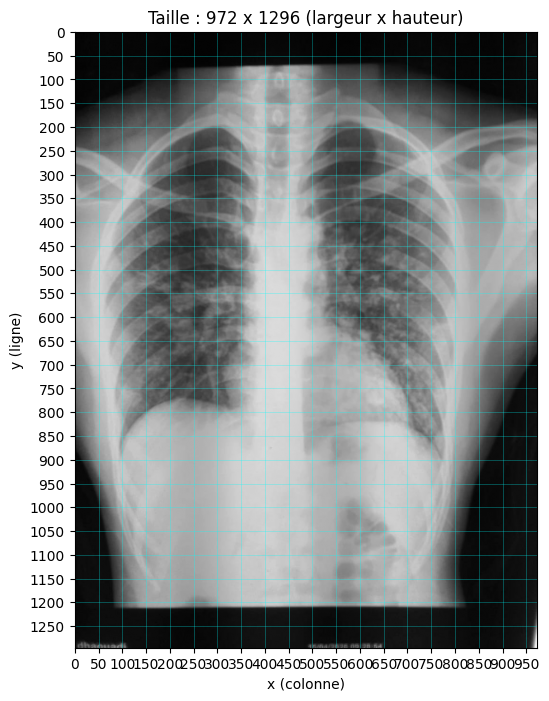

In [3]:
print("Sélectionnez votre image :")
uploaded_image = files.upload()
image_filename = list(uploaded_image.keys())[0]
print(f"Image reçue : {image_filename}")

sitk_image = load_as_sitk(image_filename)
img_arr = sitk.GetArrayFromImage(sitk_image)
print("Taille de l'image :", sitk_image.GetSize())

# Affichage avec grille de coordonnées (utile si vous choisissez ROI_METHOD = "rectangle")
display_arr = img_arr if img_arr.ndim == 2 else img_arr[img_arr.shape[0] // 2]
plt.figure(figsize=(8, 8))
plt.imshow(display_arr, cmap='gray')
plt.xticks(np.arange(0, display_arr.shape[1], 50))
plt.yticks(np.arange(0, display_arr.shape[0], 50))
plt.grid(color='cyan', alpha=0.4, linewidth=0.5)
plt.xlabel("x (colonne)")
plt.ylabel("y (ligne)")
plt.title(f"Taille : {display_arr.shape[1]} x {display_arr.shape[0]} (largeur x hauteur)")
plt.show()

Sélectionnez le masque VOI :


Saving WhatsApp Image 2026-07-09 at 18.47.54.jpeg to WhatsApp Image 2026-07-09 at 18.47.54 (1).jpeg


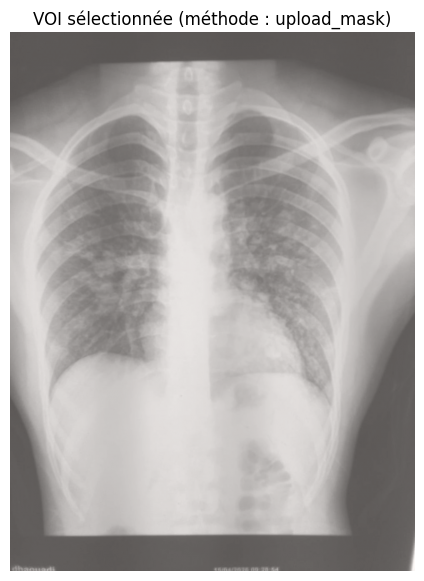

Masque VOI prêt. Taille : (972, 1296)


In [4]:
ROI_METHOD = "upload_mask"  # "upload_mask" / "rectangle" / "otsu" / "full_image"

if ROI_METHOD == "upload_mask":
    print("Sélectionnez le masque VOI :")
    uploaded_mask = files.upload()
    mask_filename = list(uploaded_mask.keys())[0]
    sitk_mask = load_as_sitk(mask_filename)
    mask_arr = (sitk.GetArrayFromImage(sitk_mask) > 0).astype(np.uint8)
    sitk_mask = sitk.GetImageFromArray(mask_arr)
    sitk_mask.CopyInformation(sitk_image)

elif ROI_METHOD == "rectangle":
    XMIN, XMAX, YMIN, YMAX = 100, 300, 150, 350
    if img_arr.ndim == 3:
        mask_arr = np.zeros(img_arr.shape, dtype=np.uint8)
        mask_arr[:, YMIN:YMAX, XMIN:XMAX] = 1
    else:
        mask_arr = np.zeros(img_arr.shape, dtype=np.uint8)
        mask_arr[YMIN:YMAX, XMIN:XMAX] = 1
    sitk_mask = sitk.GetImageFromArray(mask_arr)
    sitk_mask.CopyInformation(sitk_image)

elif ROI_METHOD == "otsu":
    otsu_filter = sitk.OtsuThresholdImageFilter()
    otsu_filter.SetInsideValue(0)
    otsu_filter.SetOutsideValue(1)
    sitk_mask = otsu_filter.Execute(sitk_image)

else:  # full_image
    mask_arr = np.ones(img_arr.shape, dtype=np.uint8)
    sitk_mask = sitk.GetImageFromArray(mask_arr)
    sitk_mask.CopyInformation(sitk_image)

# Aperçu masque superposé à l'image
mask_arr_preview = sitk.GetArrayFromImage(sitk_mask)
if mask_arr_preview.ndim == 3:
    mid = mask_arr_preview.shape[0] // 2
    mask_arr_preview = mask_arr_preview[mid]
plt.figure(figsize=(7, 7))
plt.imshow(display_arr, cmap='gray')
plt.imshow(mask_arr_preview, cmap='Reds', alpha=0.35)
plt.title(f"VOI sélectionnée (méthode : {ROI_METHOD})")
plt.axis('off')
plt.show()

print("Masque VOI prêt. Taille :", sitk_mask.GetSize())

## Étape 2-3 : Configuration PyRadiomics (7 classes + filtres LoG / Wavelet)

`IS_2D = True` par défaut (radiographie / coupe unique 2D). Mettez `False` si on travaille sur un vrai volume CT/IRM 3D.

In [5]:
IS_2D = True

settings = {
    'binWidth': 25,
    'interpolator': 'sitkBSpline',
    'normalize': True,
    'normalizeScale': 100,
    'force2D': IS_2D,
}
extractor = featureextractor.RadiomicsFeatureExtractor(**settings)
extractor.disableAllFeatures()

feature_classes = ['firstorder', 'shape2D' if IS_2D else 'shape', 'glcm', 'glrlm', 'glszm', 'ngtdm', 'gldm']
for fc in feature_classes:
    extractor.enableFeatureClassByName(fc)

extractor.enableImageTypeByName('Original')
extractor.enableImageTypeByName('LoG', customArgs={'sigma': [1.0, 2.0, 3.0]})
extractor.enableImageTypeByName('Wavelet')

print("Extracteur configuré.")
print("Classes de features :", feature_classes)
print("Filtres d'image :", list(extractor.enabledImagetypes.keys()))

Extracteur configuré.
Classes de features : ['firstorder', 'shape2D', 'glcm', 'glrlm', 'glszm', 'ngtdm', 'gldm']
Filtres d'image : ['Original', 'LoG', 'Wavelet']


## Étape 4-5 : Extraction des features

In [6]:
result = extractor.execute(sitk_image, sitk_mask)

features = {k: v for k, v in result.items() if not k.startswith('diagnostics_')}
diagnostics = {k: v for k, v in result.items() if k.startswith('diagnostics_')}

df_features = pd.DataFrame([features])
print(f"{df_features.shape[1]} features extraites pour cette image.")
df_features.T.rename(columns={0: 'valeur'})

567 features extraites pour cette image.


,valeur
original_shape2D_Elongation,0.75
original_shape2D_MajorAxisLength,1496.491452
original_shape2D_MaximumDiameter,1619.4001976040388
original_shape2D_MeshSurface,1259711.5
original_shape2D_MinorAxisLength,1122.368329
...,...
wavelet-L_gldm_LargeDependenceLowGrayLevelEmphasis,0.889376880830183
wavelet-L_gldm_LowGrayLevelEmphasis,0.1016865092526757
wavelet-L_gldm_SmallDependenceEmphasis,0.13682854140911221
wavelet-L_gldm_SmallDependenceHighGrayLevelEmphasis,19.481506972316776


## Export — tableau prêt pour relecture par le radiologue

In [7]:
output_path = '/content/features_radiomics_1_image.xlsx'

df_export = df_features.T.rename(columns={0: 'valeur'})
df_export.index.name = 'feature'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    df_export.to_excel(writer, sheet_name='Features')

print(f"Fichier généré : {output_path}")

if IN_COLAB:
    files.download(output_path)

Fichier généré : /content/features_radiomics_1_image.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>